# Lab 08: MLB Swing Probability Modeling

---
author: Your Name Here
date: April 8, 2024
embed-resources: true
---

## Introduction

In this report, we aim to develop a well calibrated probability model that estimates the probability of inducing a batter to swing given the characteristics of a pitch thrown, in addition to other information such as game situation, for a particular pitcher.

## Methods

In [131]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

### Data

In [132]:
# load data
pitches_train = pd.read_csv(
    "https://cs307.org/lab-09/data/pitches-train.csv",
)
pitches_test = pd.read_csv(
    "https://cs307.org/lab-09/data/pitches-test.csv",
)

### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a pitch thrown by Zac Gallen.

The variables considered are:

#### Response

`swing`
-   `[int64]` Whether or not the batter swung (1) or took (0).

#### Features

##### Fully Pitcher Controlled
This variable is fully controlled by the pitcher. In modern baseball, this information is communicated between the pitcher and catcher before the pitch via PitchCom.

`pitch_name`
-   `[object]` The name of the pitch type to be thrown.

##### Mostly Pitcher Controlled
These variables are largely controlled by the pitcher, but even at the highest levels of baseball, there will be variance based on skill, fatigue, etc. There variables essentially measure where the pitcher’s arm is locations as a pitch is thrown.

`release_extension`
-   `[float64]` Release extension of pitch in feet as tracked by Statcast.

`release_pos_x`
-   `[float64]` Horizontal Release Position of the ball measured in feet from the catcher’s perspective.

`release_pos_y`
-   `[float64]` Release position of pitch measured in feet from the catcher’s perspective.

`release_pos_z`
-   `[float64]` Vertical Release Position of the ball measured in feet from the catcher’s perspective.

##### Somewhat Pitcher Controlled
These variables are in some sense controlled by the pitcher, but less so than the previous variables. At the MLB level, pitchers will have some control here, but even at the highest levels, there can be a lot of variance. The speed and spin features are highly dependent on the pitch type thrown.

`release_speed`
-   `[float64]` Velocity of the pitch thrown.

`release_spin_rate`
-   `[float64]` Spin rate of pitch tracked by Statcast.

`spin_axis`
-   `[float64]` The spin axis in the 2D X-Z plane in degrees from 0 to 360, such that 180 represents a pure backspin fastball and 0 degrees represents a pure topspin (12-6) curveball.

`plate_x`
-   `[float64]` Horizontal position of the ball when it crosses home plate from the catcher’s perspective.

`plate_z`
-   `[float64]` Vertical position of the ball when it crosses home plate from the catcher’s perspective.

##### Downstream Pitcher Controlled
Theses variables are pitch characteristics, and maybe somewhat controlled by the pitcher, but are largely functions of the previous variables.

`pfx_x`
-   `[float64]` Horizontal movement in feet from the catcher’s perspective.

`pfx_z`
=   `[float64]` Vertical movement in feet from the catcher’s perspective.

##### Situational Information
These variables describe part of the game situation when the pitch was thrown. (We have omitted some other obvious variables here like score and inning for simplicity.) These are fixed before a pitch is thrown, but could have an effect. Pitchers and batters often act differently based on the game situation. For example, batters are known to “protect” when there are two strikes, thus, are much more likely to swing.

`balls`
-   `[int64]` Pre-pitch number of balls in count.

`strikes`
-   `[int64]` Pre-pitch number of strikes in count.

`on_3b`
-   `[int64]` Pre-pitch MLB Player Id of Runner on 3B.

`on_2b`
-   `[int64]` Pre-pitch MLB Player Id of Runner on 2B.

`on_1b`
-   `[int64]` Pre-pitch MLB Player Id of Runner on 1B.

`outs_when_up`
-   `[int64]` Pre-pitch number of outs.

##### Fixed Batter Information
These variables give some information about the batter facing the pitcher. In particular, are they a righty or lefty, and the size of their strike zone, which is a function of their height.

`stand`
-   `[object]` Side of the plate batter is standing.

`sz_top`
-   `[float64]` Top of the batter’s strike zone set by the operator when the ball is halfway to the plate.

`sz_bot`
-   `[float64]` Bottom of the batter’s strike zone set by the operator when the ball is halfway to the plate.


In [133]:
# summary statistics
print("Number of Samples: ", len(pitches_train))
print("Number of Features: ", len(pitches_train.columns) - 1)

Number of Samples:  2653
Number of Features:  21


In [134]:
# Swing Proportion by Pitch Type
s = pitches_train[["pitch_name","swing"]].groupby("pitch_name").agg("sum").rename(columns={'swing': 'Proportion'})
t = pitches_train[["pitch_name","swing"]].groupby("pitch_name").agg("count").rename(columns={'swing': 'Proportion'})
p = s/t
p.loc["All"] = {'Proportion': sum(pitches_train["swing"])/len(pitches_train)}
p

,Proportion
pitch_name,
4-Seam Fastball,0.471451
Changeup,0.536313
Cutter,0.453782
Knuckle Curve,0.462875
Slider,0.492188
All,0.477573


In [135]:
# Swing Proportion by Stand
s = pitches_train[["stand","swing"]].groupby("stand").agg("sum").rename(columns={'swing': 'Proportion'})
t = pitches_train[["stand","swing"]].groupby("stand").agg("count").rename(columns={'swing': 'Proportion'})
p = s/t
p.loc["All"] = {'Proportion': sum(pitches_train["swing"])/len(pitches_train)}
p

,Proportion
stand,
L,0.457586
R,0.494744
All,0.477573


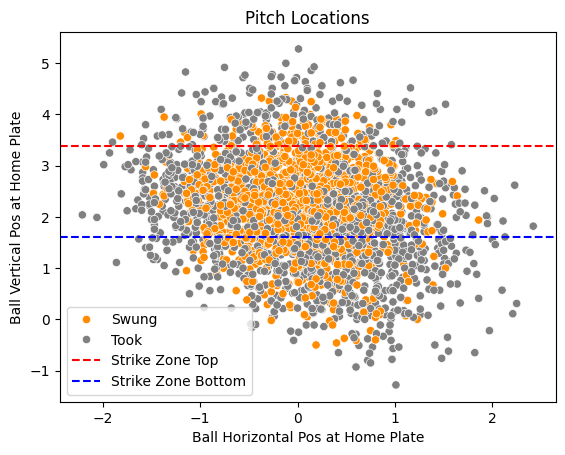

In [136]:
# Pitch Crossing Location Scatterplot
h = sns.scatterplot(pitches_train.assign(swing = pitches_train['swing'].map({0: 'Took', 1: 'Swung'})), 
                x='plate_x', y='plate_z', hue='swing', palette=['darkorange','grey'])
plt.axhline(y=pitches_train['sz_top'].mean(), color='red', linestyle='--', label='Strike Zone Top')
plt.axhline(y=pitches_train['sz_bot'].mean(), color='blue', linestyle='--', label='Strike Zone Bottom')
plt.title("Pitch Locations")
plt.xlabel("Ball Horizontal Pos at Home Plate")
plt.ylabel("Ball Vertical Pos at Home Plate")
plt.legend()
plt.show(h)


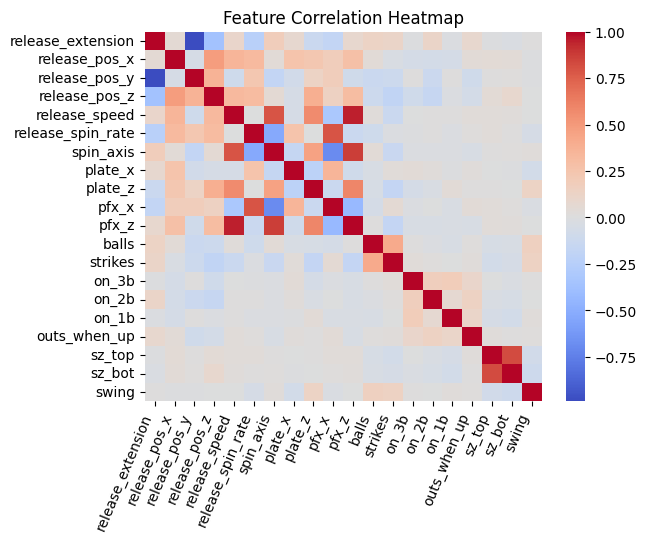

In [137]:
# Feature Correlation Heatmap
correlation = pitches_train.drop(columns=["pitch_name","stand"]).corr()
sns.heatmap(correlation, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=67.5, ha='right')
plt.show()

Given that the proportions of each pitch type being swung at are relatively similar (roughly  a 50-50 split), it is likely that the pitch type itself would not be a strong indicator of the probability of inducing a swing. The same can be said about the batter’s stand. Thus, we would want to consider other factors.

The pitch crossing location visualization shows patterns in how the location of pitches influences the batter's decision to swing. The distribution of swings within the mean strike zone boundaries is more concentrated and clustered, indicating a higher likelihood of inducing a batter to swing. There are, however, still some swings that occur outside the boundaries, suggesting that there is a lower likelihood of a batter swinging. This visualization suggests that these location-based features may be a notable predictor for the model to utilize.

There are also strong correlations among some of the features, as shown in the correlation heatmap. These can impact the model-fitting process by introducing multicollinearity, where highly correlated features can carry redundant or overlapping information. This can possibly lead to a reduction in the model's predictive accuracy and its generalization to new data.

### Models

In [138]:
# process data for ML
# create X and y for train data
X_train = pitches_train.drop(columns=["swing"])
y_train = pitches_train["swing"]

# create X and y for test data
X_test = pitches_test.drop(columns=["swing"])
y_test = pitches_test["swing"]

In [139]:
# train models

# find columns with string data type (will be considered categorical)
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

# find columns with numeric data type
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder()),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(penalty=None, max_iter=1000)), # changed from 500
    ]
)

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['release_extension',
                                                   'release_pos_x',
                                                   'release_pos_y',
                                                   'release_pos_z',
                                                   'release_speed',
                                                   'release_spin_rate',
                                                   'spin_axis', 'plate_x',
                                                   'plate_z', 'pfx_x', 'pfx_z',
                                                   'balls', 'strikes', 'on_3b',
                                                   'on_2b', 'on_1b',
                                                   'outs_when_up', 'sz_top',
                                                   'sz_bot']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['pitch_name', 'stand'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty=None))])

In [140]:
# define parameter grid
param_grid = {
    "preprocessor__cat__onehot__drop": [None, "first"],
    "preprocessor__num__scaler": [None, StandardScaler()],
    "classifier__solver": ['saga'], 
    "classifier__penalty": ['elasticnet', 'l1', 'l2', 'None'],
    "classifier__random_state": [307],
    "classifier__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9],
    "classifier__C": [0.5, 0.75, 1, 1.25, 1.5],
}

In [141]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_log_loss", refit="f1")

In [ ]:
#| warning: false
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['release_extension',
                                                                          'release_pos_x',
                                                                          'release_pos_y',
                                                                          'release_pos_z',
                                                                          'release_speed',
                                                                          'release_spin_rate',
                                                                          'spin_axis',
                                                                          'plate_x',
                                                                          'plate_z',
                                                                          'pfx_x',
                                                                          'pfx_z',
                                                                          'balls',
                                                                          'strikes',
                                                                          'on_3b...
             param_grid={'classifier__C': [0.5, 0.75, 1, 1.25, 1.5],
                         'classifier__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'classifier__penalty': ['elasticnet', 'l1', 'l2',
                                                 'None'],
                         'classifier__random_state': [307],
                         'classifier__solver': ['saga'],
                         'preprocessor__cat__onehot__drop': [None, 'first'],
                         'preprocessor__num__scaler': [None, StandardScaler()]},
             refit='f1', scoring='neg_log_loss')

In [143]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation log loss: {-grid_search.best_score_}")

Best parameters: {'classifier__C': 0.5, 'classifier__l1_ratio': 0.1, 'classifier__penalty': 'l1', 'classifier__random_state': 307, 'classifier__solver': 'saga', 'preprocessor__cat__onehot__drop': None, 'preprocessor__num__scaler': StandardScaler()}
Best cross-validation log loss: 0.6627078130571851


In [ ]:
#| warning: false
# post-processing calibration
mod = CalibratedClassifierCV(estimator=grid_search, method='isotonic')
mod.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

CalibratedClassifierCV(estimator=GridSearchCV(cv=5,
                                              estimator=Pipeline(steps=[('preprocessor',
                                                                         ColumnTransformer(transformers=[('num',
                                                                                                          Pipeline(steps=[('imputer',
                                                                                                                           SimpleImputer()),
                                                                                                                          ('scaler',
                                                                                                                           StandardScaler())]),
                                                                                                          ['release_extension',
                                                                                                           'release_pos_x',
                                                                                                           'release_pos_y',
                                                                                                           'release_pos_z',
                                                                                                           'release_speed',
                                                                                                           'release_spin_rate',
                                                                                                           'spin_axis',
                                                                                                           'plate_x',
                                                                                                           'plate_z',
                                                                                                           'pfx_x'...
                                              param_grid={'classifier__C': [0.5,
                                                                            0.75,
                                                                            1,
                                                                            1.25,
                                                                            1.5],
                                                          'classifier__l1_ratio': [0.1,
                                                                                   0.25,
                                                                                   0.5,
                                                                                   0.75,
                                                                                   0.9],
                                                          'classifier__penalty': ['elasticnet',
                                                                                  'l1',
                                                                                  'l2',
                                                                                  'None'],
                                                          'classifier__random_state': [307],
                                                          'classifier__solver': ['saga'],
                                                          'preprocessor__cat__onehot__drop': [None,
                                                                                              'first'],
                                                          'preprocessor__num__scaler': [None,
                                                                                        StandardScaler()]},
                                              refit='f1',
                                              scoring='neg_log_loss'),
                       method='isotoni

Here we used a tuning pipeline to try and find the best cross-validated logistic regression model. We then did some post-processing calibration the model.

## Results

In [145]:
# function to calculate the calibration error
def calibration_error(y_true, y_prob, type="expected", n_bins=10):
    """
    Compute calibration error of a binary classifier.

    The calibration error measures the aggregated difference between
    the average predicted probabilities assigned to the positive class,
    and the frequencies of the positive class in the actual outcome.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True targets of a binary classification task.

    y_prob : array-like of (n_samples,)
        Estimated probabilities for the positive class.

    type : {'expected', 'max'}, default='expected'
        The expected-type is the Expected Calibration Error (ECE), and the
        max-type corresponds to Maximum Calibration Error (MCE).

    n_bins : int, default=10
       The number of bins used when computing the error.

    Returns
    -------
    score : float
        The calibration error.
    """

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.searchsorted(bins[1:-1], y_prob)

    bin_sums = np.bincount(binids, weights=y_prob, minlength=len(bins))
    bin_true = np.bincount(binids, weights=y_true, minlength=len(bins))
    bin_total = np.bincount(binids, minlength=len(bins))

    nonzero = bin_total != 0
    prob_true = bin_true[nonzero] / bin_total[nonzero]
    prob_pred = bin_sums[nonzero] / bin_total[nonzero]

    if type == "max":
        calibration_error = np.max(np.abs(prob_pred - prob_true))
    elif type == "expected":
        bin_error = np.abs(prob_pred - prob_true) * bin_total[nonzero]
        calibration_error = np.sum(bin_error) / len(y_true)

    return calibration_error


# function to plot a calibration_plot
def plot_calibration_plot(y_true, y_prob):

    # generate "data" for calibration plot
    prob_true, prob_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=10,
        pos_label=1,
    )

    # create a figure and axis object with a specific size
    fig, ax = plt.subplots()

    # plot the calibration curve
    ax.plot(
        prob_pred,
        prob_true,
        "s-",
        label="Learned Classifier",
        color="#1D58A7",
    )

    # plot the diagonal "perfect" line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        label="Perfect Calibration",
        color="#F5821E",
    )

    # set the plot title and axis labels
    ax.set_title("Calibration Plot")
    ax.set_xlabel("Mean Predicted Value")
    ax.set_ylabel("Fraction of Positives")

    # add a grid
    ax.grid(
        True,
        color="lightgrey",
        linewidth=0.75,
        linestyle="--",
    )

    # fix aspect ratio
    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    # show the legend
    ax.legend()

    # show the plot
    plt.show()


0.04849668912596688
0.10043631365570471


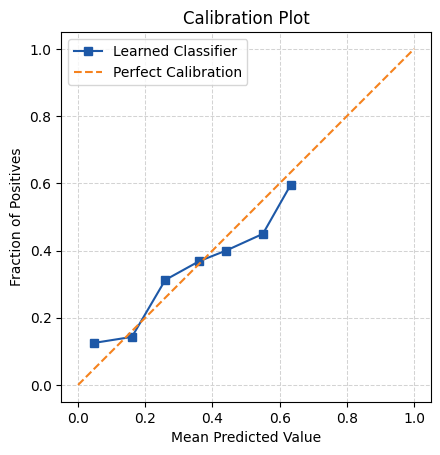

In [146]:
# final evaluation on test set
y_prob = mod.predict_proba(X_test)[:,1]
print(calibration_error(y_test, y_prob, type="expected", n_bins=10))
print(calibration_error(y_test, y_prob, type="max", n_bins=10))
plot_calibration_plot(y_test, y_prob)

Our model achieved a test Expected Calibration Error  of 0.0485 and a test Maximum Calibration Error of 0.1004.

## Discussion

Given that the model achieved a strong Expected Calibration Error (0.0485) and good Maximum Calibration Error (0.1004), this model appears to be a good predictor of the probability of inducing a swing. The model’s calibration ensures that we can trust the predicted probabilities, which is important if we plan to use this model in real world scenarios, such as an MLB coach making strategic decisions in how they guide pitchers.

This raises the question of how we can increase the batter swing probability. As a MLB coach, inducing a swing might be the ideal play, so they would want to use the model to know what variables they should focus on to maximize that likelihood. We can do this by looking at the coefficients of each feature used in the final model, since a more positive coefficient means that feature contributes more to increasing the swing probability. Below, the features are filtered by those that are relevant to the coach, being those that the pitcher can control to any extent (see Data Dictionary for full descriptions). 

We see that the most positively impactful feature is plate_z, followed by the spin_axis and pitch_name_Knuckle Curve. Hence, the coach would ask the pitcher to focus on bumping up these numerical features and possibly going for a Knuckle Curve pitch to induce a swing. 

On the other hand, the coach can also find what variables to avoid (that reduce the probability), the most important being the pitch_name_4-Seam Fastball, followed by the pitch_name_Cutter and pfx_z. Hence, the coach would ask the pitcher to avoid going for a Fastball/Cutter pitch and try to minimize (zero-out) any vertical ball movement to better induce a swing. 

In [191]:
# Find the most influential features in the final model 

# Get the pipeline from the GridSearchCV's best_estimator_
pipeline = mod.estimator.best_estimator_
pipeline

# Extract the logistic regression model from the pipeline
logistic_model = pipeline.named_steps['classifier']
logistic_model

# Create feature importance data frame, sorted
feature_importance = pd.DataFrame({
    'Feature': pipeline.named_steps['preprocessor'].get_feature_names_out(),
    'Coefficient': logistic_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Select relevant features (see Data Dictionary)
controlled_features = ['pitch_name', 'release_extension', 'release_pos_x', 'release_pos_y', 'release_pos_z', 
                       'release_speed', 'release_spin_rate', 'spin_axis', 'plate_x', 'plate_z', 'pfx_x', 'pfx_z']
filtered_list = [string for string in feature_importance['Feature'].to_list() if any(word in string for word in controlled_features)]

# Show coefficients of relevant features
feature_importance.loc[feature_importance['Feature'].isin(filtered_list)]

,Feature,Coefficient
8,num__plate_z,0.468097
6,num__spin_axis,0.289547
22,cat__pitch_name_Knuckle Curve,0.169977
3,num__release_pos_z,0.081180
9,num__pfx_x,0.050536
0,num__release_extension,0.028667
5,num__release_spin_rate,0.000000
4,num__release_speed,0.000000
20,cat__pitch_name_Changeup,0.000000
2,num__release_pos_y,0.000000


### Conclusion

Given the low expected calibration error and maximum calibration error, I recommend this model for use in practice.

In [192]:
from joblib import dump
dump(mod, "swing-probability.joblib")

['swing-probability.joblib']